In [1]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

from spot_intensity_analysis_utils import load_trackmate_spots
from spot_intensity_analysis_utils import load_trackmate_tracks
from spot_intensity_analysis_utils import load_meanint_ROIs
from spot_intensity_analysis_utils import remove_shorttracks_3
from spot_intensity_analysis_utils import remove_shorttracks_spotsfile
from spot_intensity_analysis_utils import split_table_by_track
from spot_intensity_analysis_utils import split_table_by_ROI_and_track
from spot_intensity_analysis_utils import first_10_frames
from spot_intensity_analysis_utils import meanint_tracks_ch2
from spot_intensity_analysis_utils import meanint_tracks_per_ROI_ch2

import sys
sys.path.append("..")

pd.set_option('display.max_columns', None) # Displays all columns of df

## General information

B stands for batch number, D on which day the images were acquired, pos for the specific image series, ROI for selected region of interest (ROI).

B1 = Batch20230128
B2 = Batch20230223

In [7]:
# Path to data

B2_D15_spots_path = r"/Volumes/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/Tracking_output/D15/Spots_files"
B2_D15_tracks_path = r"/Volumes/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/Tracking_output/D15/Tracks_files"

B2_D21_spots_path = r"/Volumes/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/Tracking_output/D21/Spots_files"
B2_D21_tracks_path = r"/Volumes/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/Tracking_output/D21/Tracks_files"

In [8]:
# Reads in data and creates list of dataframes; sorting happens differently than in Finder --> 12 comes before 1!

B2_D15_spots_files = sorted(glob.glob(B2_D15_spots_path + "/*.csv"))
B2_D15_tracks_files = sorted(glob.glob(B2_D15_tracks_path + "/*.csv"))
B2_D21_spots_files = sorted(glob.glob(B2_D21_spots_path + "/*.csv"))
B2_D21_tracks_files = sorted(glob.glob(B2_D21_tracks_path + "/*.csv"))

B2_D15_allpos_allROIs_spots = []
B2_D15_allpos_allROIs_tracks = []
B2_D21_allpos_allROIs_spots = []
B2_D21_allpos_allROIs_tracks = []

for file in B2_D15_spots_files:
    df = pd.read_csv(file)
    B2_D15_allpos_allROIs_spots.append(df)
    
for file in B2_D15_tracks_files:
    df = pd.read_csv(file)
    B2_D15_allpos_allROIs_tracks.append(df)
    
for file in B2_D21_spots_files:
    df = pd.read_csv(file)
    B2_D21_allpos_allROIs_spots.append(df)
    
for file in B2_D21_tracks_files:
    df = pd.read_csv(file)
    B2_D21_allpos_allROIs_tracks.append(df)

B2_D21_allpos_allROIs_spots[2].head(50)

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,Label,Spot ID,Track ID,Quality,X,Y,Z,T,Frame,Radius,Visibility,Custom Integer Spot Feature,Custom Double Spot Feature,Has max quality,Manual spot color,Mean intensity ch1,Median intensity ch1,Min intensity ch1,Max intensity ch1,Sum intensity ch1,Std intensity ch1,Mean intensity ch2,Median intensity ch2,Min intensity ch2,Max intensity ch2,Sum intensity ch2,Std intensity ch2,Contrast ch1,Signal/Noise ratio ch1,Contrast ch2,Signal/Noise ratio ch2
1,Label,Spot ID,Track ID,Quality,X,Y,Z,T,Frame,R,Visibility,Integer Spot Feature,Double Spot Feature,Max Quality,Spot color,Mean ch1,Median ch1,Min ch1,Max ch1,Sum ch1,Std ch1,Mean ch2,Median ch2,Min ch2,Max ch2,Sum ch2,Std ch2,Ctrst ch1,SNR ch1,Ctrst ch2,SNR ch2
2,NaN,NaN,NaN,(quality),(µm),(µm),(µm),(sec),NaN,(µm),NaN,NaN,NaN,NaN,NaN,(counts),(counts),(counts),(counts),(counts),(counts),(counts),(counts),(counts),(counts),(counts),(counts),NaN,NaN,NaN,NaN
3,ID81681,81681,0,1404.9632568359375,84.37977009941434,39.493384173603474,0.0,0.5,10,0.25,1,NaN,NaN,0,NaN,4746.238095238095,4789.0,3705.0,6026.0,99671.0,665.5578791331303,4979.666666666667,4936.0,2586.0,8107.0,104573.0,1262.7073823072917,0.11054491115348447,1.4196991291315426,0.13892625469068087,0.9620912656500977
4,ID81666,81666,0,2781.130126953125,84.34854281976871,39.61554820720318,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,1,NaN,5870.857142857143,5456.0,4043.0,8316.0,123288.0,1322.7446951590578,5946.190476190476,5997.0,3397.0,8765.0,124870.0,1614.77068399967,0.18142910334613266,1.363184907106189,0.19061897337892345,1.1791017489944267
5,ID81735,81735,0,2163.045166015625,84.92850733935495,39.706585157163325,0.0,0.25,5,0.25,1,NaN,NaN,0,NaN,5659.190476190476,5675.0,3809.0,7479.0,118843.0,1048.8119287578504,5882.952380952381,6009.0,2756.0,9341.0,123542.0,1466.106356175788,0.15048276412867093,1.411540463640436,0.15915297286524785,1.1018788677346911
6,ID81718,81718,0,5581.38916015625,84.60353289076282,39.48625029071536,0.0,0.4,8,0.25,1,NaN,NaN,0,NaN,7307.428571428572,6973.0,4162.0,12960.0,153456.0,2680.6442429279678,6977.047619047619,6787.0,2881.0,13961.0,146518.0,3093.2265755387284,0.3019620934250255,1.2644727689226352,0.27651115963945755,0.9771877131685917
7,ID81775,81775,0,3857.462158203125,84.56639621213078,39.530032620814936,0.0,0.35000000000000003,7,0.25,1,NaN,NaN,0,NaN,6593.142857142857,6056.0,4221.0,10222.0,138456.0,1644.5177799499247,6363.142857142857,6007.0,3053.0,10102.0,133626.0,2015.4681909103474,0.23097061299146548,1.5045026261477434,0.21232601023067435,1.1058838022975137
8,ID81694,81694,0,4478.0595703125,84.55644263060503,39.5419595748516,0.0,0.45,9,0.25,1,NaN,NaN,1,NaN,6601.0,5926.0,4093.0,11289.0,138621.0,1999.6235145646792,6395.0,6146.0,3030.0,11977.0,134295.0,2422.887347773313,0.2527925340204643,1.3322219349237105,0.24206759770067718,1.028794775970352
9,ID81680,81680,1,2194.4140625,69.23766295857725,48.36783297877917,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,0,NaN,7637.857142857143,8003.0,5115.0,9574.0,160395.0,1297.7895548090332,7667.428571428572,7547.0,4692.0,11461.0,161016.0,1543.1885034378845,0.12811057364766357,1.336689567128641,0.12666245084881853,1.1171585712928795


In [9]:
# Removes first three rows from spots file

B2_D15_allpos_allROIs_spots_clean = []
B2_D21_allpos_allROIs_spots_clean = []

for df in B2_D15_allpos_allROIs_spots:
    df = df.drop(labels=[0,1,2], axis=0, inplace=False)
    df = df.reset_index(drop=True)
    B2_D15_allpos_allROIs_spots_clean.append(df)
    
for df in B2_D21_allpos_allROIs_spots:
    df = df.drop(labels=[0,1,2], axis=0, inplace=False)
    df = df.reset_index(drop=True)
    B2_D21_allpos_allROIs_spots_clean.append(df)

B2_D21_allpos_allROIs_spots_clean[56].head(10)    

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,ID74656,74656,0,1069.0802001953125,125.44852365482397,43.13122608918887,0.0,1.1500000000000001,23,0.25,1,NaN,NaN,0,NaN,5367.571428571428,5348.0,4391.0,6119.0,112719.0,457.10781785357506,5649.666666666667,5590.0,4211.0,8117.0,118643.0,1142.0490065375186,0.08320119929656643,1.8038882652310329,0.10510114391111522,0.9409650540183727
1,ID74694,74694,0,1626.984375,125.59207615373907,43.38345290390037,0.0,1.4000000000000001,28,0.25,1,NaN,NaN,1,NaN,4900.0952380952385,4867.0,3494.0,6436.0,102902.0,811.5746364174956,5023.047619047619,5148.0,2610.0,8518.0,105484.0,1452.8395808275075,0.1164394644124103,1.2594214050063863,0.13463060630754622,0.8204817682620084
2,ID74664,74664,0,1995.9566650390625,125.62641705351128,43.452242875622666,0.0,1.1,22,0.25,1,NaN,NaN,1,NaN,5123.714285714285,5101.0,3494.0,7067.0,107598.0,1083.927079782452,5157.333333333333,4878.0,2910.0,8385.0,108304.0,1571.2425762221862,0.14533780283762548,1.199664558025329,0.16005086930568013,0.9057179239148404
3,ID74650,74650,0,3942.680908203125,125.5190583488535,43.44560966951294,0.0,1.05,21,0.25,1,NaN,NaN,1,NaN,6722.047619047619,6130.0,4157.0,10531.0,141163.0,1874.4498786628167,6521.428571428572,6269.0,3957.0,10676.0,136950.0,1976.24205428962,0.2238133635587852,1.3116820366443693,0.21701129342184328,1.1768478758399223
4,ID74684,74684,0,832.9909057617188,125.51191103696654,43.453820367917764,0.0,1.35,27,0.25,1,NaN,NaN,1,NaN,4428.0952380952385,4515.0,3280.0,5152.0,92990.0,516.9870312456499,4752.619047619048,4802.0,2473.0,6531.0,99805.0,1166.2667566294804,0.06908677104943949,1.107004125766632,0.10968411529864833,0.8055814747632197
5,ID74720,74720,1,2749.453369140625,124.97721899119915,40.85662590074136,0.0,1.6500000000000001,33,0.25,1,NaN,NaN,0,NaN,5962.238095238095,5829.0,4216.0,8554.0,125207.0,1265.8214686424742,5896.0,5855.0,3616.0,9569.0,123816.0,1665.0778960757361,0.17641582919362453,1.4126791794875955,0.17246284809594103,1.0417161056707502
6,ID74692,74692,1,1043.16943359375,125.02405472335509,40.7214713623756,0.0,1.4000000000000001,28,0.25,1,NaN,NaN,0,NaN,4909.809523809524,5059.0,3493.0,5772.0,103106.0,580.0824612973245,5296.0,5188.0,3755.0,7137.0,111216.0,934.9593039271816,0.08109843307115353,1.2698491426026048,0.11948650093394875,1.2091641058820672
7,ID74662,74662,1,1268.907470703125,125.82751799419233,41.00292611576444,0.0,1.1,22,0.25,1,NaN,NaN,0,NaN,5761.761904761905,5529.0,5144.0,6847.0,120997.0,504.0323307846338,6111.476190476191,5786.0,4147.0,8608.0,128341.0,1221.196897271182,0.079056203723728,1.675015377381905,0.12037995735367849,1.0754229039459133
8,ID74726,74726,1,1585.8968505859375,125.48631133339657,41.00368708444996,0.0,1.75,35,0.25,1,NaN,NaN,1,NaN,5293.0,5114.0,4310.0,6744.0,111153.0,725.4528930261426,5531.190476190476,5566.0,3962.0,8399.0,116155.0,1126.121379738775,0.10905563289902347,1.434886148637629,0.13504666047784236,1.1687820690304196
9,ID74667,74667,1,3042.470947265625,125.46992192579842,40.36556461953204,0.0,1.3,26,0.25,1,NaN,NaN,1,NaN,5982.523809523809,5868.0,3736.0,8816.0,125633.0,1515.955560662898,5847.619047619048,5267.0,3197.0,10157.0,122800.0,2026.8475393129715,0.1907542476188254,1.2643870496549507,0.1894372990743005,0.9189924121223657


In [10]:
# Creates list that contains indeces of dfs per time point

list_indices1 = np.arange(len(B2_D15_allpos_allROIs_spots_clean))
list_indices2 = np.arange(len(B2_D21_allpos_allROIs_spots_clean))
print(list_indices1)
print(list_indices2)

[0 1 2 3 4 5 6 7 8 9]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56]


In [11]:
# Inserts "ROI-ID" column to give an ID to each ROI belonging to one timepoint in spots file


for df, i in zip(B2_D15_allpos_allROIs_spots_clean,list_indices1):
    df = df.insert(0, "ROI_ID", value = i)

for df, i in zip(B2_D21_allpos_allROIs_spots_clean,list_indices2):
    df = df.insert(0, "ROI_ID", value = i)
    
B2_D21_allpos_allROIs_spots_clean[56].head()

,ROI_ID,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,56,ID74656,74656,0,1069.0802001953125,125.44852365482397,43.13122608918887,0.0,1.1500000000000001,23,0.25,1,NaN,NaN,0,NaN,5367.571428571428,5348.0,4391.0,6119.0,112719.0,457.10781785357506,5649.666666666667,5590.0,4211.0,8117.0,118643.0,1142.0490065375186,0.08320119929656643,1.8038882652310329,0.10510114391111522,0.9409650540183727
1,56,ID74694,74694,0,1626.984375,125.59207615373907,43.38345290390037,0.0,1.4000000000000001,28,0.25,1,NaN,NaN,1,NaN,4900.0952380952385,4867.0,3494.0,6436.0,102902.0,811.5746364174956,5023.047619047619,5148.0,2610.0,8518.0,105484.0,1452.8395808275075,0.1164394644124103,1.2594214050063863,0.13463060630754622,0.8204817682620084
2,56,ID74664,74664,0,1995.9566650390625,125.62641705351128,43.452242875622666,0.0,1.1,22,0.25,1,NaN,NaN,1,NaN,5123.714285714285,5101.0,3494.0,7067.0,107598.0,1083.927079782452,5157.333333333333,4878.0,2910.0,8385.0,108304.0,1571.2425762221862,0.14533780283762548,1.199664558025329,0.16005086930568013,0.9057179239148404
3,56,ID74650,74650,0,3942.680908203125,125.5190583488535,43.44560966951294,0.0,1.05,21,0.25,1,NaN,NaN,1,NaN,6722.047619047619,6130.0,4157.0,10531.0,141163.0,1874.4498786628167,6521.428571428572,6269.0,3957.0,10676.0,136950.0,1976.24205428962,0.2238133635587852,1.3116820366443693,0.21701129342184328,1.1768478758399223
4,56,ID74684,74684,0,832.9909057617188,125.51191103696654,43.453820367917764,0.0,1.35,27,0.25,1,NaN,NaN,1,NaN,4428.0952380952385,4515.0,3280.0,5152.0,92990.0,516.9870312456499,4752.619047619048,4802.0,2473.0,6531.0,99805.0,1166.2667566294804,0.06908677104943949,1.107004125766632,0.10968411529864833,0.8055814747632197


In [12]:
B2_D15_allpos_allROIs_spots_clean[2].head(100)

,ROI_ID,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,2,ID40544,40544,0,2008.6776123046875,106.40975264841552,42.91890294584815,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,1,NaN,5603.190476190476,5230.0,4634.0,7376.0,117667.0,835.3897066068996,5617.190476190476,5439.0,3324.0,8972.0,117961.0,1476.0921251415043,0.1330010876927766,1.574711967473629,0.13654131334488842,0.9143543430880783
1,2,ID40576,40576,0,1432.10546875,106.50273407977788,42.85973148035833,0.0,0.75,15,0.25,1,NaN,NaN,1,NaN,5207.809523809524,5020.0,4165.0,6448.0,109364.0,627.5714795182793,5242.9047619047615,4698.0,3020.0,8822.0,110101.0,1605.0448562193492,0.10274496222706496,1.5463483776207407,0.11095906572552033,0.6524985100766877
2,2,ID40547,40547,0,1675.688720703125,106.41453409120811,42.90709415717961,0.0,0.35000000000000003,7,0.25,1,NaN,NaN,1,NaN,5382.857142857143,5120.0,4487.0,6874.0,113040.0,701.3577037228781,5577.428571428572,5464.0,3152.0,7900.0,117126.0,1296.768736954611,0.11299068531497133,1.5583119143522066,0.1390748913137701,1.0502626747435786
3,2,ID40550,40550,0,2268.2109375,106.47338610789937,42.81059432957246,0.0,0.6000000000000001,12,0.25,1,NaN,NaN,1,NaN,5785.142857142857,5872.0,4159.0,7825.0,121488.0,1140.096280395401,5711.238095238095,5857.0,2272.0,8932.0,119936.0,1639.1670111602998,0.14302122315894208,1.2698392547048005,0.14122407064579623,0.862332707029506
4,2,ID40553,40553,0,1706.464599609375,106.38708619846025,42.88489266324516,0.0,0.5,10,0.25,1,NaN,NaN,1,NaN,5409.619047619048,5150.0,4376.0,6842.0,113602.0,696.8349500556409,5340.333333333333,5922.0,2432.0,8228.0,112147.0,1640.474788996568,0.11786490653478292,1.6370500115021154,0.12054630351345953,0.7004108919950089
5,2,ID40555,40555,0,2408.912109375,106.41530445945187,42.86346173014494,0.0,0.55,11,0.25,1,NaN,NaN,1,NaN,5608.428571428572,5251.0,4335.0,7960.0,117777.0,1074.9520255075836,5650.761904761905,5350.0,3186.0,8989.0,118666.0,1503.2998005974027,0.1496843175870386,1.3585630569890088,0.17334825126742381,1.110667180460102
6,2,ID40558,40558,0,2691.11767578125,106.50751108256932,42.774835535822525,0.0,0.7000000000000001,14,0.25,1,NaN,NaN,1,NaN,6031.476190476191,5542.0,4605.0,8699.0,126661.0,1183.7916040861087,5975.9047619047615,5540.0,3469.0,9678.0,125494.0,1630.6850678399526,0.15715239579474588,1.3839130522296608,0.16618762704408682,1.0444648430486438
7,2,ID40562,40562,0,1510.7869873046875,106.50787525507093,42.816299616185724,0.0,0.65,13,0.25,1,NaN,NaN,1,NaN,5218.619047619048,5247.0,3987.0,6652.0,109591.0,791.9711785280116,5486.952380952381,5434.0,3054.0,7485.0,115226.0,1327.9964787675635,0.10532395913503316,1.25578070453349,0.13619927697037135,0.9905685992047389
8,2,ID40568,40568,0,1534.1217041015625,106.5134228816658,42.84366977361202,0.0,0.9,18,0.25,1,NaN,NaN,1,NaN,5210.619047619048,5203.0,4180.0,6606.0,109423.0,694.6141717666345,5349.238095238095,5241.0,3650.0,7510.0,112334.0,1206.9911724930678,0.10599910664754521,1.4378815382252887,0.12868148512837002,1.0105609080128553
9,2,ID40537,40537,0,2587.990234375,106.42712297668506,42.87721215638904,0.0,0.25,5,0.25,1,NaN,NaN,1,NaN,6045.428571428572,5510.0,4810.0,8431.0,126954.0,1091.2978315486828,5946.571428571428,5876.0,3032.0,10751.0,124878.0,1782.169873256435,0.15900705716041866,1.5200018522173044,0.15356548158802902,0.8883802432377297


In [13]:
# Creates a list with all dfs belonging to one timepoint and removes first three rows from tracks file

B2_D15_allpos_allROIs_tracks_clean = []
B2_D21_allpos_allROIs_tracks_clean = []

for df in B2_D15_allpos_allROIs_tracks:
    df = df.drop(labels=[0,1,2], axis=0, inplace=False)
    df = df.reset_index(drop=True)
    B2_D15_allpos_allROIs_tracks_clean.append(df)
    
for df in B2_D21_allpos_allROIs_tracks:
    df = df.drop(labels=[0,1,2], axis=0, inplace=False)
    df = df.reset_index(drop=True)
    B2_D21_allpos_allROIs_tracks_clean.append(df)

B2_D15_allpos_allROIs_tracks_clean[2].head(10)

,LABEL,TRACK_INDEX,TRACK_ID,MANUAL_INTEGER_TRACK_FEATURE,MANUAL_DOUBLE_TRACK_FEATURE,NUMBER_SPOTS,NUMBER_GAPS,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,LONGEST_GAP,TRACK_DURATION,TRACK_START,TRACK_STOP,TRACK_DISPLACEMENT,TRACK_X_LOCATION,TRACK_Y_LOCATION,TRACK_Z_LOCATION,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TOTAL_DISTANCE_TRAVELED,MAX_DISTANCE_TRAVELED,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED,LINEARITY_OF_FORWARD_PROGRESSION,MEAN_DIRECTIONAL_CHANGE_RATE
0,Track_112,0,0,NaN,NaN,14,0,0,0,0,0,0.65,0.25,0.9,0.09258922746219689,106.46122755685822,42.85867519413961,0.0,0.9648868695313484,2.098188610713579,0.20223688018892755,0.7309533356058493,0.6356267195388251,1974.7063249860491,0.6271764651953764,0.13016612464954466,0.1476286700798853,0.14244496532645676,0.14762867007988528,34.729929062502144
1,Track_113,1,1,NaN,NaN,3,0,0,0,0,0,0.09999999999999998,0.6000000000000001,0.7000000000000001,0.2872768502427231,107.74795171466542,43.044494222573384,0.0,3.529891732340258,3.6639375716475056,3.3958458930330107,3.6639375716475056,0.18956944392799388,982.0494791666666,0.35298917323402573,0.2872768502427231,0.8138404008563274,2.8727685024272316,0.8138404008563275,24.823238708176465
2,Track_114,2,2,NaN,NaN,2,0,0,0,0,0,0.050000000000000044,1.25,1.3,0.13344906345167953,107.7885830711416,42.21610550338632,0.0,2.6689812690335883,2.6689812690335883,2.6689812690335883,2.6689812690335883,NaN,1161.3461608886719,0.13344906345167953,0.13344906345167953,1.0,2.6689812690335883,1.0,NaN
3,Track_115,3,3,NaN,NaN,3,0,0,0,0,0,0.09999999999999987,1.2000000000000002,1.3,0.18017084949265752,107.69750276317818,43.1129377161854,0.0,1.8529572436605262,3.0834267091931915,0.6224877781278607,3.0834267091931915,1.740146606242269,1162.8543294270833,0.18529572436605207,0.18017084949265752,0.9723421849536563,1.8017084949265776,0.9723421849536548,12.707895618132047
4,Track_116,4,4,NaN,NaN,3,0,0,0,0,0,0.09999999999999964,2.0500000000000003,2.15,0.22077919512819782,107.53235508384155,39.51482026214878,0.0,6.070377696310853,8.070154907617479,4.070600485004228,8.070154907617479,2.8281120539544764,1034.401835123698,0.6070377696310831,0.4035077453808725,0.363699272390205,2.207791951281986,0.363699272390205,56.27341960638477


In [14]:
# Inserts "ROI-ID" column to give an ID to each ROI belonging to one timepoint in tracks file


for df, i in zip(B2_D15_allpos_allROIs_tracks_clean,list_indices1):
    df = df.insert(0, "ROI_ID", value = i)

for df, i in zip(B2_D21_allpos_allROIs_tracks_clean,list_indices2):
    df = df.insert(0, "ROI_ID", value = i)
    
B2_D15_allpos_allROIs_tracks_clean[2].head()

,ROI_ID,LABEL,TRACK_INDEX,TRACK_ID,MANUAL_INTEGER_TRACK_FEATURE,MANUAL_DOUBLE_TRACK_FEATURE,NUMBER_SPOTS,NUMBER_GAPS,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,LONGEST_GAP,TRACK_DURATION,TRACK_START,TRACK_STOP,TRACK_DISPLACEMENT,TRACK_X_LOCATION,TRACK_Y_LOCATION,TRACK_Z_LOCATION,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TOTAL_DISTANCE_TRAVELED,MAX_DISTANCE_TRAVELED,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED,LINEARITY_OF_FORWARD_PROGRESSION,MEAN_DIRECTIONAL_CHANGE_RATE
0,2,Track_112,0,0,NaN,NaN,14,0,0,0,0,0,0.65,0.25,0.9,0.09258922746219689,106.46122755685822,42.85867519413961,0.0,0.9648868695313484,2.098188610713579,0.20223688018892755,0.7309533356058493,0.6356267195388251,1974.7063249860491,0.6271764651953764,0.13016612464954466,0.1476286700798853,0.14244496532645676,0.14762867007988528,34.729929062502144
1,2,Track_113,1,1,NaN,NaN,3,0,0,0,0,0,0.09999999999999998,0.6000000000000001,0.7000000000000001,0.2872768502427231,107.74795171466542,43.044494222573384,0.0,3.529891732340258,3.6639375716475056,3.3958458930330107,3.6639375716475056,0.18956944392799388,982.0494791666666,0.35298917323402573,0.2872768502427231,0.8138404008563274,2.8727685024272316,0.8138404008563275,24.823238708176465
2,2,Track_114,2,2,NaN,NaN,2,0,0,0,0,0,0.050000000000000044,1.25,1.3,0.13344906345167953,107.7885830711416,42.21610550338632,0.0,2.6689812690335883,2.6689812690335883,2.6689812690335883,2.6689812690335883,NaN,1161.3461608886719,0.13344906345167953,0.13344906345167953,1.0,2.6689812690335883,1.0,NaN
3,2,Track_115,3,3,NaN,NaN,3,0,0,0,0,0,0.09999999999999987,1.2000000000000002,1.3,0.18017084949265752,107.69750276317818,43.1129377161854,0.0,1.8529572436605262,3.0834267091931915,0.6224877781278607,3.0834267091931915,1.740146606242269,1162.8543294270833,0.18529572436605207,0.18017084949265752,0.9723421849536563,1.8017084949265776,0.9723421849536548,12.707895618132047
4,2,Track_116,4,4,NaN,NaN,3,0,0,0,0,0,0.09999999999999964,2.0500000000000003,2.15,0.22077919512819782,107.53235508384155,39.51482026214878,0.0,6.070377696310853,8.070154907617479,4.070600485004228,8.070154907617479,2.8281120539544764,1034.401835123698,0.6070377696310831,0.4035077453808725,0.363699272390205,2.207791951281986,0.363699272390205,56.27341960638477


In [15]:
B2_D15_allpos_allROIs_tracks_clean[2].head()

,ROI_ID,LABEL,TRACK_INDEX,TRACK_ID,MANUAL_INTEGER_TRACK_FEATURE,MANUAL_DOUBLE_TRACK_FEATURE,NUMBER_SPOTS,NUMBER_GAPS,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,LONGEST_GAP,TRACK_DURATION,TRACK_START,TRACK_STOP,TRACK_DISPLACEMENT,TRACK_X_LOCATION,TRACK_Y_LOCATION,TRACK_Z_LOCATION,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TOTAL_DISTANCE_TRAVELED,MAX_DISTANCE_TRAVELED,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED,LINEARITY_OF_FORWARD_PROGRESSION,MEAN_DIRECTIONAL_CHANGE_RATE
0,2,Track_112,0,0,NaN,NaN,14,0,0,0,0,0,0.65,0.25,0.9,0.09258922746219689,106.46122755685822,42.85867519413961,0.0,0.9648868695313484,2.098188610713579,0.20223688018892755,0.7309533356058493,0.6356267195388251,1974.7063249860491,0.6271764651953764,0.13016612464954466,0.1476286700798853,0.14244496532645676,0.14762867007988528,34.729929062502144
1,2,Track_113,1,1,NaN,NaN,3,0,0,0,0,0,0.09999999999999998,0.6000000000000001,0.7000000000000001,0.2872768502427231,107.74795171466542,43.044494222573384,0.0,3.529891732340258,3.6639375716475056,3.3958458930330107,3.6639375716475056,0.18956944392799388,982.0494791666666,0.35298917323402573,0.2872768502427231,0.8138404008563274,2.8727685024272316,0.8138404008563275,24.823238708176465
2,2,Track_114,2,2,NaN,NaN,2,0,0,0,0,0,0.050000000000000044,1.25,1.3,0.13344906345167953,107.7885830711416,42.21610550338632,0.0,2.6689812690335883,2.6689812690335883,2.6689812690335883,2.6689812690335883,NaN,1161.3461608886719,0.13344906345167953,0.13344906345167953,1.0,2.6689812690335883,1.0,NaN
3,2,Track_115,3,3,NaN,NaN,3,0,0,0,0,0,0.09999999999999987,1.2000000000000002,1.3,0.18017084949265752,107.69750276317818,43.1129377161854,0.0,1.8529572436605262,3.0834267091931915,0.6224877781278607,3.0834267091931915,1.740146606242269,1162.8543294270833,0.18529572436605207,0.18017084949265752,0.9723421849536563,1.8017084949265776,0.9723421849536548,12.707895618132047
4,2,Track_116,4,4,NaN,NaN,3,0,0,0,0,0,0.09999999999999964,2.0500000000000003,2.15,0.22077919512819782,107.53235508384155,39.51482026214878,0.0,6.070377696310853,8.070154907617479,4.070600485004228,8.070154907617479,2.8281120539544764,1034.401835123698,0.6070377696310831,0.4035077453808725,0.363699272390205,2.207791951281986,0.363699272390205,56.27341960638477


In [16]:
# Removes tracks that are <= 3 from tracks file

B2_D15_allpos_allROIs_tracks_filtered = []
B2_D21_allpos_allROIs_tracks_filtered = []

for df in B2_D15_allpos_allROIs_tracks_clean:
    df = remove_shorttracks_3(df)
    B2_D15_allpos_allROIs_tracks_filtered.append(df)
    
for df in B2_D21_allpos_allROIs_tracks_clean:
    df = remove_shorttracks_3(df)
    B2_D21_allpos_allROIs_tracks_filtered.append(df)

B2_D15_allpos_allROIs_tracks_filtered[2].head(100)

,ROI_ID,LABEL,TRACK_INDEX,TRACK_ID,MANUAL_INTEGER_TRACK_FEATURE,MANUAL_DOUBLE_TRACK_FEATURE,NUMBER_SPOTS,NUMBER_GAPS,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,LONGEST_GAP,TRACK_DURATION,TRACK_START,TRACK_STOP,TRACK_DISPLACEMENT,TRACK_X_LOCATION,TRACK_Y_LOCATION,TRACK_Z_LOCATION,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TOTAL_DISTANCE_TRAVELED,MAX_DISTANCE_TRAVELED,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED,LINEARITY_OF_FORWARD_PROGRESSION,MEAN_DIRECTIONAL_CHANGE_RATE
0,2,Track_112,0,0,NaN,NaN,14,0,0,0,0,0,0.65,0.25,0.9,0.09258922746219689,106.46122755685822,42.85867519413961,0.0,0.9648868695313484,2.098188610713579,0.20223688018892755,0.7309533356058493,0.6356267195388251,1974.7063249860491,0.6271764651953764,0.13016612464954466,0.1476286700798853,0.14244496532645676,0.14762867007988528,34.729929062502144


In [17]:
# Creates trackIDs object 

B2_D15_allpos_allROIs_trackIDs = []
B2_D21_allpos_allROIs_trackIDs = []

for df in B2_D15_allpos_allROIs_tracks_filtered:
    ID = df["TRACK_ID"].unique()
    B2_D15_allpos_allROIs_trackIDs.append(ID)

for df in B2_D21_allpos_allROIs_tracks_filtered:
    ID = df["TRACK_ID"].unique()
    B2_D21_allpos_allROIs_trackIDs.append(ID)

B2_D21_allpos_allROIs_trackIDs[2]

array(['0', '2', '3', '4', '11', '13', '15', '16', '17', '19', '20', '22',
       '23', '24', '25'], dtype=object)

In [18]:
# Removes spots from spots file from tracks <= 3 in length

B2_D15_allpos_allROIs_spots_filtered = []
B2_D21_allpos_allROIs_spots_filtered = []


for df, i in zip(B2_D15_allpos_allROIs_spots_clean, B2_D15_allpos_allROIs_trackIDs):
    
    df = remove_shorttracks_spotsfile(df, i)
    B2_D15_allpos_allROIs_spots_filtered.append(df)

for df, i in zip(B2_D21_allpos_allROIs_spots_clean, B2_D21_allpos_allROIs_trackIDs):
    
    df = remove_shorttracks_spotsfile(df, i)
    B2_D21_allpos_allROIs_spots_filtered.append(df)


pd.set_option('display.max_rows', None) # Displays all rows of df  
B2_D15_allpos_allROIs_spots_filtered[2].head(100)

,ROI_ID,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,2,ID40544,40544,0,2008.6776123046875,106.40975264841552,42.91890294584815,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,1,NaN,5603.190476190476,5230.0,4634.0,7376.0,117667.0,835.3897066068996,5617.190476190476,5439.0,3324.0,8972.0,117961.0,1476.0921251415043,0.1330010876927766,1.574711967473629,0.13654131334488842,0.9143543430880783
1,2,ID40576,40576,0,1432.10546875,106.50273407977788,42.85973148035833,0.0,0.75,15,0.25,1,NaN,NaN,1,NaN,5207.809523809524,5020.0,4165.0,6448.0,109364.0,627.5714795182793,5242.9047619047615,4698.0,3020.0,8822.0,110101.0,1605.0448562193492,0.10274496222706496,1.5463483776207407,0.11095906572552033,0.6524985100766877
2,2,ID40547,40547,0,1675.688720703125,106.41453409120811,42.90709415717961,0.0,0.35000000000000003,7,0.25,1,NaN,NaN,1,NaN,5382.857142857143,5120.0,4487.0,6874.0,113040.0,701.3577037228781,5577.428571428572,5464.0,3152.0,7900.0,117126.0,1296.768736954611,0.11299068531497133,1.5583119143522066,0.1390748913137701,1.0502626747435786
3,2,ID40550,40550,0,2268.2109375,106.47338610789937,42.81059432957246,0.0,0.6000000000000001,12,0.25,1,NaN,NaN,1,NaN,5785.142857142857,5872.0,4159.0,7825.0,121488.0,1140.096280395401,5711.238095238095,5857.0,2272.0,8932.0,119936.0,1639.1670111602998,0.14302122315894208,1.2698392547048005,0.14122407064579623,0.862332707029506
4,2,ID40553,40553,0,1706.464599609375,106.38708619846025,42.88489266324516,0.0,0.5,10,0.25,1,NaN,NaN,1,NaN,5409.619047619048,5150.0,4376.0,6842.0,113602.0,696.8349500556409,5340.333333333333,5922.0,2432.0,8228.0,112147.0,1640.474788996568,0.11786490653478292,1.6370500115021154,0.12054630351345953,0.7004108919950089
5,2,ID40555,40555,0,2408.912109375,106.41530445945187,42.86346173014494,0.0,0.55,11,0.25,1,NaN,NaN,1,NaN,5608.428571428572,5251.0,4335.0,7960.0,117777.0,1074.9520255075836,5650.761904761905,5350.0,3186.0,8989.0,118666.0,1503.2998005974027,0.1496843175870386,1.3585630569890088,0.17334825126742381,1.110667180460102
6,2,ID40558,40558,0,2691.11767578125,106.50751108256932,42.774835535822525,0.0,0.7000000000000001,14,0.25,1,NaN,NaN,1,NaN,6031.476190476191,5542.0,4605.0,8699.0,126661.0,1183.7916040861087,5975.9047619047615,5540.0,3469.0,9678.0,125494.0,1630.6850678399526,0.15715239579474588,1.3839130522296608,0.16618762704408682,1.0444648430486438
7,2,ID40562,40562,0,1510.7869873046875,106.50787525507093,42.816299616185724,0.0,0.65,13,0.25,1,NaN,NaN,1,NaN,5218.619047619048,5247.0,3987.0,6652.0,109591.0,791.9711785280116,5486.952380952381,5434.0,3054.0,7485.0,115226.0,1327.9964787675635,0.10532395913503316,1.25578070453349,0.13619927697037135,0.9905685992047389
8,2,ID40568,40568,0,1534.1217041015625,106.5134228816658,42.84366977361202,0.0,0.9,18,0.25,1,NaN,NaN,1,NaN,5210.619047619048,5203.0,4180.0,6606.0,109423.0,694.6141717666345,5349.238095238095,5241.0,3650.0,7510.0,112334.0,1206.9911724930678,0.10599910664754521,1.4378815382252887,0.12868148512837002,1.0105609080128553
9,2,ID40537,40537,0,2587.990234375,106.42712297668506,42.87721215638904,0.0,0.25,5,0.25,1,NaN,NaN,1,NaN,6045.428571428572,5510.0,4810.0,8431.0,126954.0,1091.2978315486828,5946.571428571428,5876.0,3032.0,10751.0,124878.0,1782.169873256435,0.15900705716041866,1.5200018522173044,0.15356548158802902,0.8883802432377297


In [19]:
# Concatenates all ROIs/timepoint into one df

B2_D15_allpos_allROIs = pd.concat(B2_D15_allpos_allROIs_spots_filtered)
B2_D21_allpos_allROIs = pd.concat(B2_D21_allpos_allROIs_spots_filtered)

#pd.set_option('display.max_rows', None) # Displays all rows of df  
B2_D21_allpos_allROIs.head(100)

,ROI_ID,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,0,ID78641,78641,0,1744.1220703125,60.20530368859475,67.82234084737314,0.0,0.25,5,0.25,1,NaN,NaN,0,NaN,5046.714285714285,5094.0,3398.0,6440.0,105981.0,858.0373618238978,5362.0952380952385,5126.0,2709.0,9924.0,112604.0,1461.7412871216952,0.13818016107351777,1.4281282111452613,0.16687792228496845,1.0492221882583432
1,0,ID78721,78721,0,1632.023193359375,60.28990557877236,68.32157730919404,0.0,0.35000000000000003,7,0.25,1,NaN,NaN,0,NaN,5677.523809523809,5547.0,4797.0,6944.0,119228.0,598.2133916126936,5863.476190476191,5900.0,3729.0,8832.0,123133.0,1232.3016927298127,0.12074702778215644,2.0450394132300205,0.13671225765768524,1.1445243285148226
2,0,ID78658,78658,0,4736.8447265625,60.525780670303234,68.72411411560428,0.0,0.45,9,0.25,1,NaN,NaN,0,NaN,7121.761904761905,6588.0,4262.0,11561.0,149557.0,2170.5807495866607,7091.523809523809,7868.0,2912.0,10533.0,148922.0,2108.5290279967126,0.26535857022443093,1.3761348917015481,0.2597716175664254,1.387042779367666
3,0,ID78710,78710,0,4479.9365234375,60.8326417826769,68.27052343976712,0.0,0.6000000000000001,12,0.25,1,NaN,NaN,0,NaN,7306.809523809524,7277.0,4766.0,11178.0,153443.0,2066.9689794248875,7097.619047619048,6487.0,3538.0,11405.0,149050.0,2224.5685756161906,0.25622289220124317,1.4420325009985286,0.2415496062790315,1.2414783222579127
4,0,ID78698,78698,0,2250.450439453125,60.729935132156655,68.39497806469241,0.0,0.5,10,0.25,1,NaN,NaN,0,NaN,5506.285714285715,5462.0,4125.0,7488.0,115632.0,1031.4749217919525,5619.571428571428,5585.0,3107.0,8272.0,118011.0,1399.5426599939199,0.1562528483922665,1.4427968724856328,0.17311586067871307,1.1850672689101187
5,0,ID78684,78684,0,4834.19482421875,60.40933772915349,68.73197704434104,0.0,0.4,8,0.25,1,NaN,NaN,0,NaN,7016.619047619048,6126.0,4441.0,11820.0,147349.0,2110.416107695127,6707.571428571428,5930.0,3404.0,12158.0,140859.0,2355.1215376584832,0.2698410699140736,1.41302056236113,0.24828266013337885,1.13296222449589
6,0,ID78734,78734,0,956.930908203125,60.18708455313426,68.10571319444293,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,0,NaN,4566.476190476191,4552.0,3795.0,5276.0,95896.0,415.98769441506545,4636.809523809524,4370.0,2816.0,7222.0,97373.0,1239.2594812648247,0.08579766278553516,1.7348313612575998,0.10784957135175846,0.7284917377584867
7,0,ID78670,78670,0,2362.525634765625,60.98229929893538,68.78868471632384,0.0,0.55,11,0.25,1,NaN,NaN,0,NaN,5720.285714285715,5356.0,4662.0,7607.0,120126.0,919.2596011387176,5822.380952380952,5555.0,4571.0,8660.0,122270.0,1114.8050267284623,0.17033831142187475,1.8113837114882607,0.17223591993667972,1.5347597422294548
8,0,ID78659,78659,1,1633.9349365234375,45.43434087201903,69.54917418853103,0.0,0.45,9,0.25,1,NaN,NaN,0,NaN,4033.6190476190477,4040.0,2907.0,5674.0,84706.0,772.6983548701573,4127.190476190476,4057.0,2493.0,6109.0,86671.0,1149.0419321786137,0.13861406485819838,1.2710002689404545,0.1640963120999695,1.0126480670456668
9,0,ID78818,78818,1,1595.968017578125,45.92216554062024,69.70033633308354,0.0,0.8500000000000001,17,0.25,1,NaN,NaN,0,NaN,4203.047619047619,4201.0,2910.0,5798.0,88264.0,811.7323127848538,4426.190476190476,4389.0,2631.0,6411.0,92950.0,1158.5451919993288,0.13008964431829154,1.192096197751683,0.1719637485091008,1.1211657986165098


In [20]:
# Splits tables into seperate dfs by ROI and TRACK_ID

B2_D15_allpos_allROIs_singletracks = [j for i,j in split_table_by_ROI_and_track(B2_D15_allpos_allROIs)]
B2_D21_allpos_allROIs_singletracks = [j for i,j in split_table_by_ROI_and_track(B2_D21_allpos_allROIs)]
B2_D15_allpos_allROIs_singletracks[24].head()

,ROI_ID,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
113,1,ID35955,35955,3,1797.94482421875,121.94459941563441,28.689264504437045,0.0,0.25,5,0.25,1,NaN,NaN,0,NaN,7574.619047619048,7420.0,6450.0,9057.0,159067.0,772.9673651707732,7373.380952380952,6831.0,5455.0,10266.0,154841.0,1462.3374260474386,0.09332172972384235,1.6728786289637247,0.08483950995203614,0.7886453203093738
114,1,ID36003,36003,3,2672.65185546875,122.20717248607335,29.023244525875022,0.0,0.5,10,0.25,1,NaN,NaN,0,NaN,7798.714285714285,7487.0,6197.0,10148.0,163773.0,1161.3785404792507,7748.666666666667,7447.0,4832.0,11503.0,162722.0,1810.6754632825102,0.12908546579868557,1.535428995423344,0.12812539372191453,0.9720625143939041
115,1,ID35908,35908,3,1780.5303955078125,122.05800610582556,28.83730193677923,0.0,0.35000000000000003,7,0.25,1,NaN,NaN,0,NaN,7196.952380952381,7082.0,5799.0,8851.0,151136.0,851.4824998900726,7471.952380952381,7421.0,4349.0,11049.0,156911.0,1959.8946266621194,0.08622440549315745,1.3418795999735817,0.1270182396250055,0.8593429405896149
116,1,ID35882,35882,3,968.2210693359375,122.28566387085652,28.90835346956778,0.0,0.45,9,0.25,1,NaN,NaN,0,NaN,6406.476190476191,6338.0,5155.0,7556.0,134536.0,675.5979291744179,6697.809523809524,6515.0,4182.0,10037.0,140654.0,1469.8234118099908,0.04896755923004131,0.8853343250488537,0.08406946544717629,0.7067711306214024
117,1,ID36028,36028,3,3629.057373046875,121.9294961213207,28.56370756627845,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,0,NaN,8089.619047619048,7631.0,6175.0,11422.0,169882.0,1543.554355252528,7986.523809523809,7305.0,5074.0,12051.0,167717.0,1967.7963212448492,0.16768284220018415,1.505219605958203,0.15877158268016425,1.1121992038520436


In [21]:
# Sorts the seperated dfs by FRAME and extracts the first 10

B2_D15_allpos_allROIs_tracks10 = []
B2_D21_allpos_allROIs_tracks10 = []

for df in B2_D15_allpos_allROIs_singletracks:
    df = first_10_frames(df)
    B2_D15_allpos_allROIs_tracks10.append(df)
    
for df in B2_D21_allpos_allROIs_singletracks:
    df = first_10_frames(df)
    B2_D21_allpos_allROIs_tracks10.append(df)
        
B2_D15_allpos_allROIs_tracks10[2].head(10)

,ROI_ID,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
94,0,ID34807,34807,3,2837.66650390625,90.1136971308147,85.89661042801619,0.0,0.25,5,0.25,1,NaN,NaN,1,NaN,5249.285714285715,4686.0,3848.0,7921.0,110235.0,1301.4295272067998,5328.0952380952385,4782.0,3602.0,8334.0,111890.0,1371.5521829213026,0.20675940378857804,1.3821466671169633,0.21563827287801887,1.3781964248652843
85,0,ID34793,34793,3,2297.95556640625,90.05294511243896,86.01066205813893,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,1,NaN,4820.428571428572,4536.0,3507.0,6841.0,101229.0,976.5338484368358,4596.714285714285,4058.0,2667.0,8524.0,96531.0,1770.9449495356184,0.18029183135882124,1.5080474097407544,0.15936722758278538,0.71359277249973
28,0,ID34820,34820,3,1926.38818359375,89.76795843317039,85.96728846943857,0.0,0.35000000000000003,7,0.25,1,NaN,NaN,1,NaN,5007.380952380952,4918.0,3479.0,6518.0,105155.0,947.7452968066091,4933.0952380952385,4492.0,2793.0,8043.0,103595.0,1441.6431217455277,0.1629525825537333,1.4806357493873261,0.15040083490944844,0.8947316296088044
31,0,ID34824,34824,3,2763.322509765625,89.59525746412336,85.88702381412892,0.0,0.4,8,0.25,1,NaN,NaN,1,NaN,5649.571428571428,5554.0,3880.0,7997.0,118641.0,1203.724867709751,5698.047619047619,5564.0,2552.0,10010.0,119659.0,1603.2289754177496,0.20365255431216683,1.5882065640972631,0.19995460348000774,1.1844782971472378
98,0,ID34814,34814,3,3305.108642578125,89.71403381160141,85.8894043932552,0.0,0.45,9,0.25,1,NaN,NaN,1,NaN,5625.714285714285,5604.0,3564.0,8644.0,118140.0,1576.9901440039866,5541.9047619047615,5434.0,2256.0,9480.0,116380.0,2000.214861077727,0.23730675390057115,1.3683947633724711,0.22240281365788347,1.0081806100277124
40,0,ID34835,34835,3,2395.404052734375,89.63417870377424,85.74035757827629,0.0,0.5,10,0.25,1,NaN,NaN,0,NaN,5515.047619047619,5246.0,4150.0,7371.0,115816.0,934.6918998360088,5460.571428571428,5382.0,3026.0,7897.0,114672.0,1323.7548704888143,0.18764898162263774,1.8645279346220118,0.17759472192467746,1.2442129609878436
88,0,ID34798,34798,3,3555.50634765625,89.55933257384345,85.64049549564108,0.0,0.55,11,0.25,1,NaN,NaN,1,NaN,5671.666666666667,5274.0,3469.0,8906.0,119105.0,1627.9241792335827,5623.9047619047615,5255.0,3304.0,10403.0,118102.0,1839.1793524493992,0.2481722426344817,1.3854319715246348,0.24989269283489346,1.2227134750585706
36,0,ID34830,34830,3,2642.35302734375,89.58766586450878,85.78386198862664,0.0,0.6000000000000001,12,0.25,1,NaN,NaN,1,NaN,5330.952380952381,5273.0,3635.0,7615.0,111950.0,1229.5475784283617,5264.428571428572,5104.0,2485.0,8853.0,110553.0,1631.9958201977283,0.19839790911329178,1.4355737492992582,0.2062053495977589,1.102912017249974
44,0,ID34842,34842,3,2760.09033203125,89.72341085096453,85.82431597954724,0.0,0.65,13,0.25,1,NaN,NaN,1,NaN,5518.047619047619,5472.0,3519.0,7799.0,115879.0,1368.2458651934776,5403.0952380952385,5330.0,2763.0,9000.0,113465.0,1587.718265460277,0.20879954831315045,1.393242009745126,0.1987642945741317,1.1285056821650026
48,0,ID34848,34848,3,3281.919189453125,90.0480373308496,85.67759948076315,0.0,0.7000000000000001,14,0.25,1,NaN,NaN,1,NaN,5413.952380952381,5293.0,3354.0,8602.0,113693.0,1574.4043469258613,5228.761904761905,4251.0,2853.0,10273.0,109804.0,2065.6886722050326,0.2267855540240427,1.2713785523536651,0.22052274331436722,0.9146848883270015


In [22]:
# Concatenates all filtered seperate track dfs into one df per timepoint

B2_D15_allpos_allROIs_alltracks10 = pd.concat(B2_D15_allpos_allROIs_tracks10)
B2_D21_allpos_allROIs_alltracks10 = pd.concat(B2_D21_allpos_allROIs_tracks10)
    
B2_D15_allpos_allROIs_alltracks10.head()

,ROI_ID,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
9,0,ID34802,34802,0,1267.7371826171875,100.90080872357147,83.31951620013108,0.0,0.25,5,0.25,1,NaN,NaN,0,NaN,6227.666666666667,6244.0,5299.0,7271.0,130781.0,605.4392069674158,6612.476190476191,6151.0,4718.0,8981.0,138862.0,1231.4555866553865,0.07677984398864161,1.4669155794794826,0.11351292668739643,1.094776387210279
1,0,ID34789,34789,0,1838.37158203125,101.19115690703919,83.38229715498892,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,0,NaN,6576.380952380952,6590.0,5184.0,7838.0,138104.0,764.3150185748332,6748.9047619047615,7067.0,4413.0,9076.0,141727.0,1320.7075340423369,0.12063336140869392,1.8524583283104707,0.13816343411418258,1.2406381460587788
17,0,ID34815,34815,0,1522.3814697265625,101.03374277766471,83.36219178662321,0.0,0.35000000000000003,7,0.25,1,NaN,NaN,0,NaN,6201.0952380952385,6068.0,5203.0,7454.0,130223.0,607.0674513397919,6269.476190476191,6128.0,3635.0,9193.0,131659.0,1441.2501385619228,0.09519807374671227,1.7758118037926889,0.10627973384074349,0.835809672193867
2,0,ID34822,34822,0,2438.07470703125,100.65093339489289,83.51121718763002,0.0,0.4,8,0.25,1,NaN,NaN,0,NaN,6084.476190476191,5727.0,4960.0,8453.0,127774.0,1049.4583659701618,6367.809523809524,5917.0,3088.0,10484.0,133724.0,1455.0431134178677,0.14270147315964257,1.4480502966534126,0.16200476522939977,1.2202928821868066
13,0,ID34811,34811,0,908.1793212890625,100.41563346284009,83.89619280707637,0.0,0.45,9,0.25,1,NaN,NaN,0,NaN,5136.142857142857,5225.0,4466.0,5783.0,107859.0,417.91928475655266,5377.523809523809,5304.0,3463.0,8972.0,112928.0,1485.4525781406694,0.0715937294013125,1.642175243711201,0.11214736976871295,0.7300965547357291


In [23]:
# Extracts the columns "ROI_ID", "TRACK_ID" and "MEAN_INTENSITY_CH2"(merged) and calculates the mean of each track

B2_D15_allpos_allROIs_meanint = meanint_tracks_per_ROI_ch2(B2_D15_allpos_allROIs_alltracks10)
B2_D21_allpos_allROIs_meanint = meanint_tracks_per_ROI_ch2(B2_D21_allpos_allROIs_alltracks10)

B2_D21_allpos_allROIs_meanint.head()

,ROI_ID,TRACK_ID,MEAN_INTENSITY_CH2
0,0,0,6025.13
1,0,1,4974.12
2,0,2,6557.39
3,0,4,5927.11
4,0,5,4899.56


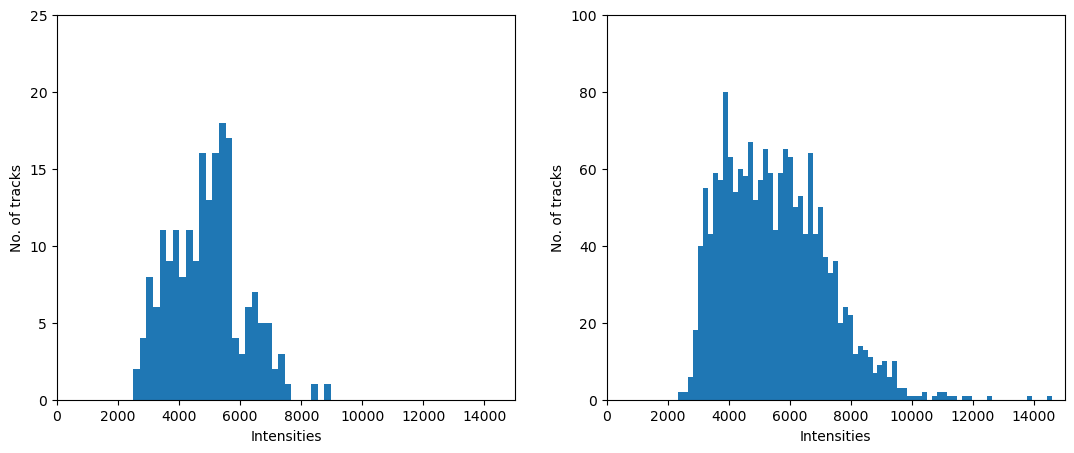

In [24]:
# Plots distribution of track intensities

fig, ax = plt.subplots(1,2, figsize = (13,5)) # ; sign removes output lines
ax[0].hist(B2_D15_allpos_allROIs_meanint["MEAN_INTENSITY_CH2"], 30);
ax[1].hist(B2_D21_allpos_allROIs_meanint["MEAN_INTENSITY_CH2"], 75);
ax[0].set_ylim(0,25);
ax[1].set_ylim(0,100);
ax[0].set_xlim(0,15000);
ax[1].set_xlim(0,15000);
ax[0].set_xlabel('Intensities');
ax[1].set_xlabel('Intensities');
ax[0].set_ylabel('No. of tracks');
ax[1].set_ylabel('No. of tracks');

## Further steps

Here I will somehow need to normalize the spot intensites based on their background since intensities in different ROIs can vary quite a lot. One idea would be to normalize by the avarage spot intensity of all spots in one ROI. This would probably work well if I was expecting a unimodal distribution, but since I might have a bi- or even trimodal distribution, this is probably not a good idea, since the distribution might vary quite a lot depending on the ROI. Another option would be to divide all spot intensities by the average intensity of the whole ROI. This could already improve the situation but even within one ROI backgrounds can potentially vary. Would it make more sense to only look a the immedate vicinity of a spot, i.e. a handful of pixels in the x,y direction surrounding the spot and divide the spot intensity value by the average immediate environment intensity? How far out would we have to go? What about spots that are very close together?